In [7]:
# Cell 1 — Imports, settings, and loading data/model

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import json
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Paths
processed_path = "../data/processed"
models_path    = "../models"

# Load datasets (with lifestyle features + cluster + Stress_Level)
train_df = pd.read_csv(os.path.join(processed_path, "train_with_clusters.csv"))
val_df   = pd.read_csv(os.path.join(processed_path, "val_with_clusters.csv"))
test_df  = pd.read_csv(os.path.join(processed_path, "test_with_clusters.csv"))

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

# Load trained model (Model B: lifestyle + cluster)
model_B = joblib.load(os.path.join(models_path, "multinomial_logreg_lifestyle_cluster.pkl"))

# Load feature config
with open(os.path.join(models_path, "model_config.json"), "r") as f:
    config = json.load(f)

features_B = config["features_model_B"]   # lifestyle + cluster
target_col = config["target"]
class_labels = config["classes"]

print("\nModel and config loaded.")
print("Features used by Model B:", features_B)
print("Target column:", target_col)
print("Class labels:", class_labels)


Train shape: (7866, 13)
Val shape:   (2245, 13)
Test shape:  (1124, 13)

Model and config loaded.
Features used by Model B: ['Sleep_Hours_Scaled', 'Work_Hours_Scaled', 'Physical_Activity_Hours_Scaled', 'Social_Media_Usage_Scaled', 'Diet_Quality_Encoded_Scaled', 'Smoking_Habit_Encoded_Scaled', 'Alcohol_Consumption_Encoded_Scaled', 'Cluster']
Target column: Stress_Level
Class labels: ['High', 'Low', 'Medium']


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
# Cell 2 — Prepare validation and test sets for evaluation

X_val  = val_df[features_B]
y_val  = val_df[target_col]

X_test = test_df[features_B]
y_test = test_df[target_col]

print("X_val shape: ", X_val.shape, " y_val:", y_val.shape)
print("X_test shape:", X_test.shape, " y_test:", y_test.shape)


X_val shape:  (2245, 8)  y_val: (2245,)
X_test shape: (1124, 8)  y_test: (1124,)


In [9]:
# Cell 3 — Accuracy and classification report for validation and test sets

# Validation predictions
val_pred = model_B.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
val_report = classification_report(y_val, val_pred, digits=3, output_dict=True)
report_val_df = pd.DataFrame(val_report).T

print("===== MODEL B (Lifestyle + Cluster) — VALIDATION =====")
print("Validation Accuracy:", round(val_acc, 4))
print()
print("Classification Report (Validation):")
print(classification_report(y_val, val_pred, digits=3))

# Test predictions
test_pred = model_B.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
test_report = classification_report(y_test, test_pred, digits=3, output_dict=True)
report_test_df = pd.DataFrame(test_report).T

print()
print("===== MODEL B (Lifestyle + Cluster) — TEST =====")
print("Test Accuracy:", round(test_acc, 4))
print()
print("Classification Report (Test):")
print(classification_report(y_test, test_pred, digits=3))


===== MODEL B (Lifestyle + Cluster) — VALIDATION =====
Validation Accuracy: 0.9354

Classification Report (Validation):
              precision    recall  f1-score   support

        High      0.955     0.956     0.956      1077
         Low      0.972     0.942     0.957       591
      Medium      0.864     0.889     0.876       577

    accuracy                          0.935      2245
   macro avg      0.930     0.929     0.930      2245
weighted avg      0.936     0.935     0.936      2245


===== MODEL B (Lifestyle + Cluster) — TEST =====
Test Accuracy: 0.9324

Classification Report (Test):
              precision    recall  f1-score   support

        High      0.953     0.946     0.950       539
         Low      0.979     0.946     0.962       296
      Medium      0.851     0.893     0.872       289

    accuracy                          0.932      1124
   macro avg      0.928     0.928     0.928      1124
weighted avg      0.934     0.932     0.933      1124



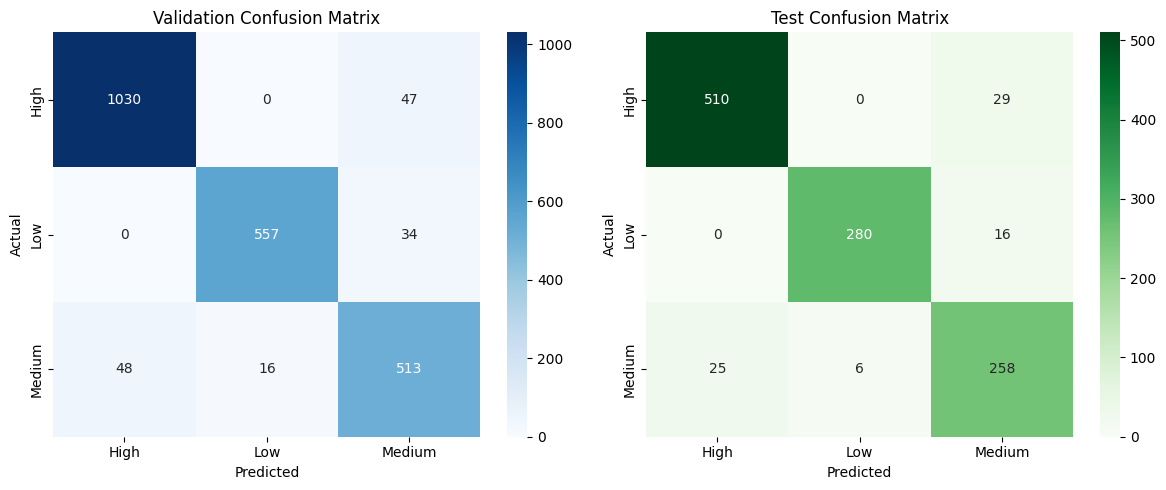

In [10]:
# Cell 4 — Confusion matrices for validation and test sets

# Ensure consistent class order
classes_sorted = sorted(list(set(list(y_test.unique()) + list(y_val.unique()))))

cm_val = confusion_matrix(y_val, val_pred, labels=classes_sorted)
cm_test = confusion_matrix(y_test, test_pred, labels=classes_sorted)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_sorted, yticklabels=classes_sorted, ax=axes[0])
axes[0].set_title("Validation Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes_sorted, yticklabels=classes_sorted, ax=axes[1])
axes[1].set_title("Test Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


Validation Macro AUC-ROC: 0.990


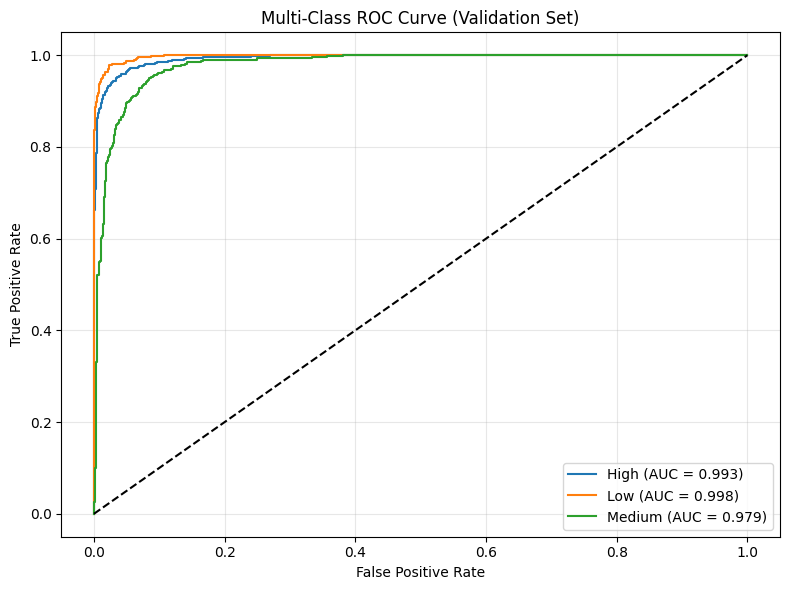

In [11]:
# Cell 5 — Multi-class ROC Curve (Validation Set)

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# True labels + features
X_val = val_df[features_B]
y_val = val_df[target_col]

# Binarize labels
classes = class_labels  # ["Low", "Medium", "High"]
y_val_bin = label_binarize(y_val, classes=classes)

# Predict probabilities
val_probs = model_B.predict_proba(X_val)

# Compute AUC (macro)
auc_val = roc_auc_score(y_val_bin, val_probs, average="macro", multi_class="ovr")
print(f"Validation Macro AUC-ROC: {auc_val:.3f}")

# --- Plot ROC curves ---
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], val_probs[:, i])
    auc_score = roc_auc_score(y_val_bin[:, i], val_probs[:, i])
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {auc_score:.3f})")

# Random chance line
plt.plot([0, 1], [0, 1], 'k--')

plt.title("Multi-Class ROC Curve (Validation Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


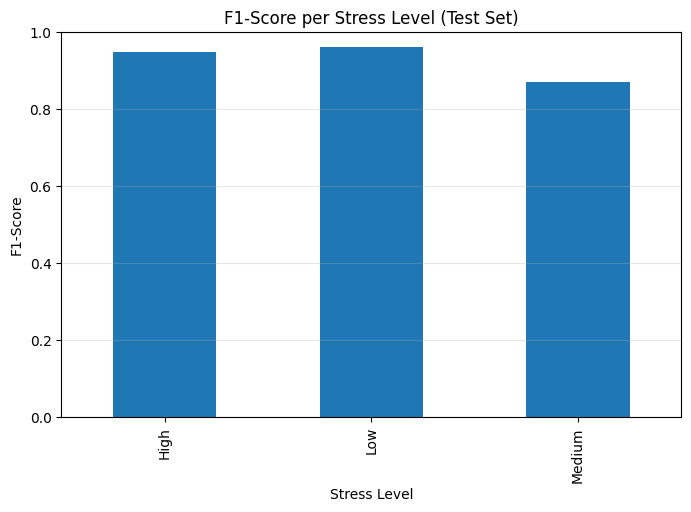

Per-class F1 scores (Test):


,precision,recall,f1-score
High,0.953,0.946,0.950
Low,0.979,0.946,0.962
Medium,0.851,0.893,0.872


In [12]:
# Cell 6 — F1-score per class for TEST set (bar plot)

if "report_test_df" not in globals():
    test_pred = model_B.predict(X_test)
    test_report = classification_report(y_test, test_pred, digits=3, output_dict=True)
    report_test_df = pd.DataFrame(test_report).T

# Filter out 'accuracy', 'macro avg', 'weighted avg'
per_class_test = report_test_df.loc[class_labels, ["precision", "recall", "f1-score"]]

plt.figure(figsize=(8, 5))
per_class_test["f1-score"].plot(kind="bar")
plt.title("F1-Score per Stress Level (Test Set)")
plt.ylabel("F1-Score")
plt.xlabel("Stress Level")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Per-class F1 scores (Test):")
display(per_class_test.round(3))


In [13]:
# Cell 7 — Text summary of evaluation (for thesis write-up)

summary_text = f"""
Final Evaluation Summary (Model B — Lifestyle + Cluster):

• Validation Accuracy: {val_acc:.3f}
• Test Accuracy:       {test_acc:.3f}

Per-class performance on the TEST set:
"""

print(summary_text)
print(per_class_test.round(3))



Final Evaluation Summary (Model B — Lifestyle + Cluster):

• Validation Accuracy: 0.935
• Test Accuracy:       0.932

Per-class performance on the TEST set:

        precision  recall  f1-score
High        0.953   0.946     0.950
Low         0.979   0.946     0.962
Medium      0.851   0.893     0.872
